In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Q1-Read the data https://raw.githubusercontent.com/ogut77/DataScience/main/data/diamond.csv
url = "https://raw.githubusercontent.com/ogut77/DataScience/main/data/diamond.csv"
df = pd.read_csv(url)
df.head()

,Carat Weight,Cut,Color,Clarity,Polish,Symmetry,Report,Price
0,1.10,Ideal,H,SI1,VG,EX,GIA,5169
1,0.83,Ideal,H,VS1,ID,ID,AGSL,3470
2,0.85,Ideal,H,SI1,EX,EX,GIA,3183
3,0.91,Ideal,E,SI1,VG,VG,GIA,4370
4,0.83,Ideal,G,SI1,EX,EX,GIA,3171


The description of dataset is given below.

•	ID: Uniquely identifies each observation (diamond)

•	Carat Weight: The weight of the diamond in metric carats. One carat is equal to 0.2 grams, roughly the same weight as a paperclip

•	Cut: One of five values indicating the cut of the diamond in the following order of desirability (Signature-Ideal, Ideal, Very Good, Good, Fair)

•	Color: One of six values indicating the diamond's color in the following order of desirability (D, E, F - Colorless, G, H, I - Near colorless)

•	Clarity: One of seven values indicating the diamond's clarity in the following order of desirability (F - Flawless, IF - Internally Flawless, VVS1 or VVS2 - Very, Very Slightly Included, or VS1 or VS2 - Very Slightly Included, SI1 - Slightly Included)

•	Polish: One of four values indicating the diamond's polish (ID - Ideal, EX - Excellent, VG - Very Good, G - Good)

•	Symmetry: One of four values indicating the diamond's symmetry (ID - Ideal, EX - Excellent, VG - Very Good, G - Good)

•	Report: One of of two values "AGSL" or "GIA" indicating which grading agency reported the qualities of the diamond qualities

•	Price: The The amount in USD that the diamond is valued


In [9]:
#Q2-Get first 2 rows of data
df.head(2)

,Carat Weight,Cut,Color,Clarity,Polish,Symmetry,Report,Price
0,1.10,Ideal,H,SI1,VG,EX,GIA,5169
1,0.83,Ideal,H,VS1,ID,ID,AGSL,3470


In [10]:
#Q3-Check if there is missing value
df.isnull().sum()

,0
Carat Weight,0
Cut,0
Color,0
Clarity,0
Polish,0
Symmetry,0
Report,0
Price,0


In [11]:
#Q4- Get data information and number of rows and columns
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Carat Weight  6000 non-null   float64
 1   Cut           6000 non-null   object 
 2   Color         6000 non-null   object 
 3   Clarity       6000 non-null   object 
 4   Polish        6000 non-null   object 
 5   Symmetry      6000 non-null   object 
 6   Report        6000 non-null   object 
 7   Price         6000 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 375.1+ KB


(6000, 8)

In [12]:
#Q5-Get descriptive statistics of data
df.describe()

,Carat Weight,Price
count,6000.000000,6000.000000
mean,1.334520,11791.579333
std,0.475696,10184.350051
min,0.750000,2184.000000
25%,1.000000,5150.500000
50%,1.130000,7857.000000
75%,1.590000,15036.500000
max,2.910000,101561.000000


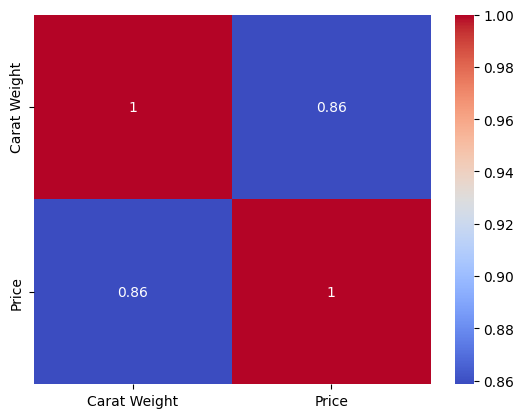

In [13]:
#Q6-Use seasoborns heat map to generate following heatmap
# annot = True to print the correlation inside the square

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.show()

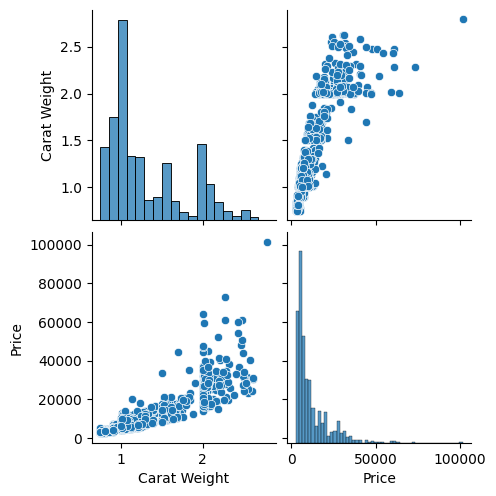

In [14]:
#Q7-Use seasoborns paiplot to generate following  diagram

sns.pairplot(df.sample(1000))
plt.show()

In [16]:
#Q8-Divide the data so that get Price as ouput variable (Y) and other variables as input varable (X)
y = df['Price']

X = df.drop('Price', axis=1)

In [17]:
#Q9-Create dummy for the input variables (X)

X = pd.get_dummies(X, drop_first=True)
X.head()

,Carat Weight,Cut_Good,Cut_Ideal,Cut_Signature-Ideal,Cut_Very Good,Color_E,Color_F,Color_G,Color_H,Color_I,...,Clarity_VS2,Clarity_VVS1,Clarity_VVS2,Polish_G,Polish_ID,Polish_VG,Symmetry_G,Symmetry_ID,Symmetry_VG,Report_GIA
0,1.10,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
1,0.83,False,True,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,True,False,False
2,0.85,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,0.91,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
4,0.83,False,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [20]:
#Q10 -Split the input and output data into two parts: test data (20%) and train data(%80)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape[0])
print(X_test.shape[0])

4800
1200


In [21]:
def evalmetric(y,ypred):
 import numpy as np
 e = y - ypred
 mse_f = np.mean(e**2)
 rmse_f = np.sqrt(mse_f)
 mae_f = np.mean(abs(e))
 mape_f = 100*np.mean(abs(e/y))
 r2_f = 1-(sum(e**2)/sum((y-np.mean(y))**2))
 print("MSE:", mse_f)
 print("RMSE:", rmse_f)
 print("MAE:",mae_f)
 print("MAPE:",mape_f)
 print("R-Squared:", r2_f)

In [23]:
#Q11 Use Linear regression to evaluate the performance of test and train data of Linear model  using evalmetric
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 4. Evaluate Performance
print("Train Data")
evalmetric(y_train, y_pred_train)

print("Test Data")
evalmetric(y_test, y_pred_test)

Train Data
MSE: 13617878.611029424
RMSE: 3690.240996334714
MAE: 2420.3923973752335
MAPE: 28.436213974145286
R-Squared: 0.8677546171602643
Test Data
MSE: 16395263.35943688
RMSE: 4049.1064890216066
MAE: 2386.8817587054814
MAPE: 27.98432467278652
R-Squared: 0.8461544250476118


Q12 -Based on the performance of test and training model, can we say there is overfitting or not in the performace of liner model?

Answer: the performance is highly consistent between the two sets, as the R square values (0.86 vs. 0.84) and MAPE (28.4% vs. 27.9%) are very close. While the error is somewhat high, the model is generalizing well to new data rather than just memorizing the training set.

In [24]:
#Q13- Use Lasso regression to evaluate the performance of test and train data   using evalmetric

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

y_pred_lasso_train = lasso_model.predict(X_train)
y_pred_lasso_test = lasso_model.predict(X_test)

print("Lasso Train")
evalmetric(y_train, y_pred_lasso_train)

print("Lasso Test")
evalmetric(y_test, y_pred_lasso_test)

Lasso Train
MSE: 13704193.75938769
RMSE: 3701.917578686442
MAE: 2426.0635544173574
MAPE: 28.51702753318953
R-Squared: 0.8669163970405562
Lasso Test
MSE: 16374369.089371083
RMSE: 4046.5255577311113
MAE: 2392.1989557555003
MAPE: 28.070122459545804
R-Squared: 0.8463504872224614


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+10, tolerance: 4.943e+07
  model = cd_fast.enet_coordinate_descent(


In [25]:
#Q14 Use Ridge regreesionto evaluate the performance of test and train data   using evalmetric

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(X_test)

print("Ridge Train")
evalmetric(y_train, y_pred_ridge_train)

print("Ridge Test")
evalmetric(y_test, y_pred_ridge_test)

Ridge Train
MSE: 13945142.760987546
RMSE: 3734.3195847419843
MAE: 2436.0590762300158
MAPE: 28.66555995681942
R-Squared: 0.8645765030033441
Ridge Test
MSE: 16354795.887182316
RMSE: 4044.1063150197124
MAE: 2400.4165468663386
MAPE: 28.230792730281756
R-Squared: 0.8465341531068316


Q15- Did you get any improvement on test data using Ridge and Lasso?
Explain why?

Answer: There is nearly no practical improvement, as the R square (roughly 0.846) and RMSE remain nearly identical to the original linear model. As I think the reason is that because the dataset's features are likely not complex or redundant enough for the L1/L2 penalties to provide a significant advantage. Additionally, the Lasso convergence warning that I have suggests the model struggled to find an optimal solution

In [26]:
#Q16-Use Decison Tree Regression to evaluate the performance of test and train data   using evalmetric

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

print("Decision Tree Train")
evalmetric(y_train, y_pred_dt_train)

print("Decision Tree Test Performance")
evalmetric(y_test, y_pred_dt_test)

Decision Tree Train
MSE: 83753.97633482143
RMSE: 289.40279254841585
MAE: 77.53468948412699
MAPE: 0.7629440866398477
R-Squared: 0.999186651828738
Decision Tree Test Performance
MSE: 3377642.2571009025
RMSE: 1837.836297688372
MAE: 888.5465218253969
MAPE: 7.167853834215014
R-Squared: 0.9683057659010963


In [27]:
#Q17-Use Random Forest to evaluate the performance of test and train data   using evalmetric

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

print("Random Forest Train")
evalmetric(y_train, y_pred_rf_train)

print("Random Forest Test")
evalmetric(y_test, y_pred_rf_test)

Random Forest Train
MSE: 459930.07480541855
RMSE: 678.181446815982
MAE: 315.2863189831003
MAPE: 2.5137504528128867
R-Squared: 0.995533545968541
Random Forest Test
MSE: 1662704.1117658145
RMSE: 1289.4588445413117
MAE: 664.0046578063602
MAPE: 5.445649651388347
R-Squared: 0.9843979529671247


Q18-Why Random forest perform better than Decison Tree on test data?

Answer: Random Forest performs better because it is an ensemble method that averages the predictions of many different trees, which cancels out individual errors and reduces overfitting. While the single Decision Tree essentially memorized the training data (as seen by its near-perfect 0.999 R square score), the Random Forest is more robust and generalizes much better to the unseen test data.

Q19- Which regression technique among Linear Regresssion, Lasso Regression ,Ridge Regression, Decision Tree and Random Forest  provide best performance on test data?

Answer: Random Forest provided the best performance, achieving the highest R square score (0.984) and the lowest RMSE (1289) on the test set. It significantly outperformed the linear models (which struggled with a 28% MAPE) and the single Decision Tree by providing the most accurate and stable predictions.
